# 03 — Modelado y Evaluación: Cox Proportional Hazards

**Objetivo:** Entrenar y evaluar un modelo de supervivencia para predecir el riesgo de muerte.

## ¿Qué predice exactamente este modelo?

El **modelo de Cox Proportional Hazards** no predice *si* alguien va a morir (todos morimos), sino **cuándo** y **con qué riesgo relativo** comparado con el resto de la población.

Formalmente, estima el **hazard ratio** de cada variable:

> *Un hazard ratio de 1.5 en `egfr` significa que un participante con eGFR más bajo tiene un 50% más de riesgo instantáneo de morir que el participante de referencia.*

**¿Por qué Cox y no regresión logística?**  
La regresión logística ignora el *tiempo* hasta el evento. Cox aprovecha que algunos participantes murieron a los 10 meses y otros a los 83 meses — esa información temporal es clave para un modelo clínico útil. También maneja naturalmente los datos **censurados** (participantes que no murieron durante el seguimiento).

**Pregunta de negocio respondida:**  
> *¿Qué variables clínicas predicen mejor la supervivencia a largo plazo en adultos estadounidenses?*

In [1]:
%pip install pandas scikit-learn lifelines pyarrow matplotlib --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import json
import pickle
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from lifelines import CoxPHFitter, KaplanMeierFitter
from lifelines.utils import concordance_index
from sklearn.model_selection import train_test_split

PRIM    = Path('data/03_primary/nhanes_2013_2014')
FEAT    = Path('data/04_feature/nhanes_2013_2014')
MODELS  = Path('data/06_models/nhanes_2013_2014')
REPORT  = Path('data/08_reporting/nhanes_2013_2014')
for p in [FEAT, MODELS, REPORT]:
    p.mkdir(parents=True, exist_ok=True)

DURATION_COL = 'permth_int'
EVENT_COL    = 'mortstat'
TEST_SIZE    = 0.2
RANDOM_STATE = 42

print('Entorno listo.')

Entorno listo.


## 1. Carga del dataset de features

In [2]:
features = pd.read_parquet(PRIM / 'features.parquet')
print(f'Features: {features.shape[0]:,} registros × {features.shape[1]} columnas')
print(f'Tasa de eventos (muertes): {features[EVENT_COL].mean()*100:.2f}%')
features.head(3)

Features: 5,913 registros × 10 columnas
Tasa de eventos (muertes): 7.51%


,RIDAGEYR,RIAGENDR,LBXSCR,is_female,egfr,bmi,map,ever_smoked,permth_int,mortstat
0,69.0,1.0,1.21,0,63.196389,26.7,88.666667,1,78.0,0
1,54.0,1.0,0.79,0,108.636396,28.6,93.333333,1,58.0,1
2,72.0,1.0,1.22,0,62.060490,28.9,106.666667,1,83.0,0


## 2. División Train / Test

Usamos `stratify=mortstat` para que la tasa de eventos sea **igual en train y test**. Sin estratificación, una split aleatoria podría concentrar todas las muertes en un solo set, lo que sesgaría tanto el entrenamiento como la evaluación.

In [3]:
train, test = train_test_split(
    features,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=features[EVENT_COL],
)

print(f'Train: {len(train):,} | Test: {len(test):,}')
print(f'Tasa eventos train: {train[EVENT_COL].mean()*100:.2f}%')
print(f'Tasa eventos test:  {test[EVENT_COL].mean()*100:.2f}%')

train.to_parquet(FEAT / 'train.parquet', index=False)
test.to_parquet(FEAT  / 'test.parquet',  index=False)
print('\n✓ Train y test guardados.')

Train: 4,730 | Test: 1,183
Tasa eventos train: 7.51%
Tasa eventos test:  7.52%

✓ Train y test guardados.


## 3. Curva de Kaplan-Meier (baseline visual)

Antes de entrenar el modelo Cox, visualizamos la curva de supervivencia global. Esta curva responde: *¿qué porcentaje de participantes sobrevivió hasta cada mes?*

También comparamos por **sexo** para ver si hay diferencias baseline — si las hay, el modelo deberá capturarlas.

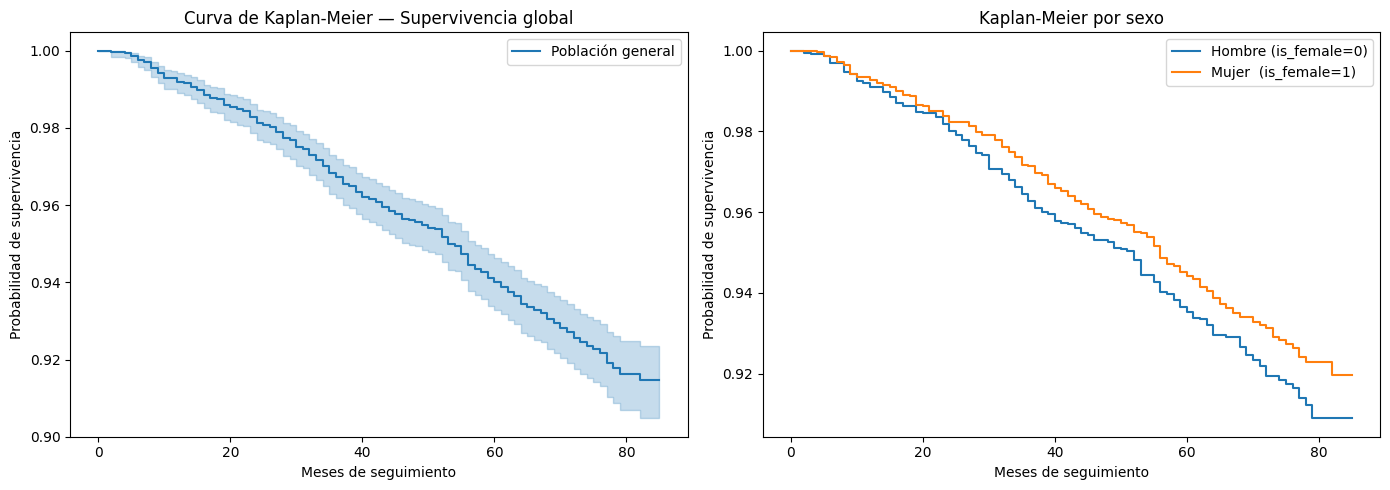

✓ Gráfico guardado en data\08_reporting\nhanes_2013_2014\kaplan_meier.png


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Global
kmf = KaplanMeierFitter()
kmf.fit(train[DURATION_COL], train[EVENT_COL], label='Población general')
kmf.plot_survival_function(ax=axes[0], ci_show=True)
axes[0].set_title('Curva de Kaplan-Meier — Supervivencia global')
axes[0].set_xlabel('Meses de seguimiento')
axes[0].set_ylabel('Probabilidad de supervivencia')

# Por sexo
for label, mask in [('Hombre (is_female=0)', train['is_female']==0),
                     ('Mujer  (is_female=1)', train['is_female']==1)]:
    kmf_s = KaplanMeierFitter()
    kmf_s.fit(train.loc[mask, DURATION_COL], train.loc[mask, EVENT_COL], label=label)
    kmf_s.plot_survival_function(ax=axes[1], ci_show=False)

axes[1].set_title('Kaplan-Meier por sexo')
axes[1].set_xlabel('Meses de seguimiento')
axes[1].set_ylabel('Probabilidad de supervivencia')
plt.tight_layout()
plt.savefig(REPORT / 'kaplan_meier.png', dpi=120, bbox_inches='tight')
plt.show()
print('✓ Gráfico guardado en', REPORT / 'kaplan_meier.png')

## 4. Entrenamiento del modelo Cox

Usamos `penalizer=0.1` (regularización L2) para estabilizar los coeficientes cuando hay covariables correlacionadas (ej. `LBXSCR` y `egfr` derivan de la misma medición). Sin penalización, los coeficientes podrían divergir o ser inestables con variables colineales.

In [5]:
# Limpieza de NaN en train
num_cols = [c for c in train.columns if c not in {DURATION_COL, EVENT_COL}]
train_clean = train.dropna(subset=[DURATION_COL, EVENT_COL] + num_cols).copy()
print(f'Filas antes de dropna: {len(train):,} → después: {len(train_clean):,}')

cph = CoxPHFitter(penalizer=0.1)
cph.fit(
    train_clean,
    duration_col=DURATION_COL,
    event_col=EVENT_COL,
    show_progress=True,
)
print(f'\nC-index (train): {cph.concordance_index_:.4f}')

Filas antes de dropna: 4,730 → después: 4,103
Iteration 1: norm_delta = 5.27e-01, step_size = 0.9500, log_lik = -2258.79363, newton_decrement = 1.17e+02, seconds_since_start = 0.0
Iteration 2: norm_delta = 4.80e-02, step_size = 0.9500, log_lik = -2200.93743, newton_decrement = 3.29e+01, seconds_since_start = 0.0
Iteration 3: norm_delta = 3.17e-02, step_size = 0.9500, log_lik = -2161.67426, newton_decrement = 9.45e+00, seconds_since_start = 0.0
Iteration 4: norm_delta = 2.47e-02, step_size = 1.0000, log_lik = -2149.99410, newton_decrement = 2.51e+00, seconds_since_start = 0.0
Iteration 5: norm_delta = 1.36e-02, step_size = 1.0000, log_lik = -2146.99135, newton_decrement = 3.94e-01, seconds_since_start = 0.0
Iteration 6: norm_delta = 3.16e-03, step_size = 1.0000, log_lik = -2146.55351, newton_decrement = 1.49e-02, seconds_since_start = 0.0
Iteration 7: norm_delta = 1.34e-04, step_size = 1.0000, log_lik = -2146.53820, newton_decrement = 2.48e-05, seconds_since_start = 0.0
Iteration 8: nor

### Coeficientes del modelo

`exp(coef)` = **Hazard Ratio**. Un valor > 1 aumenta el riesgo; < 1 lo reduce.

Columnas clave:
- `exp(coef)`: hazard ratio
- `p`: significancia estadística (< 0.05 = significativo)
- `exp(coef) lower/upper 95%`: intervalo de confianza del HR

In [6]:
summary = cph.summary[['coef','exp(coef)','p','exp(coef) lower 95%','exp(coef) upper 95%']]
summary.sort_values('p').round(4)

,coef,exp(coef),p,exp(coef) lower 95%,exp(coef) upper 95%
covariate,,,,,
RIDAGEYR,0.0241,1.0243,0.0000,1.0200,1.0288
egfr,-0.0091,0.9910,0.0000,0.9879,0.9940
LBXSCR,0.1444,1.1553,0.0011,1.0597,1.2595
ever_smoked,0.2096,1.2332,0.0066,1.0600,1.4347
bmi,-0.0055,0.9945,0.3314,0.9835,1.0056
RIAGENDR,-0.0178,0.9824,0.8321,0.8337,1.1577
is_female,-0.0178,0.9824,0.8321,0.8337,1.1577
map,0.0006,1.0006,0.8527,0.9944,1.0068


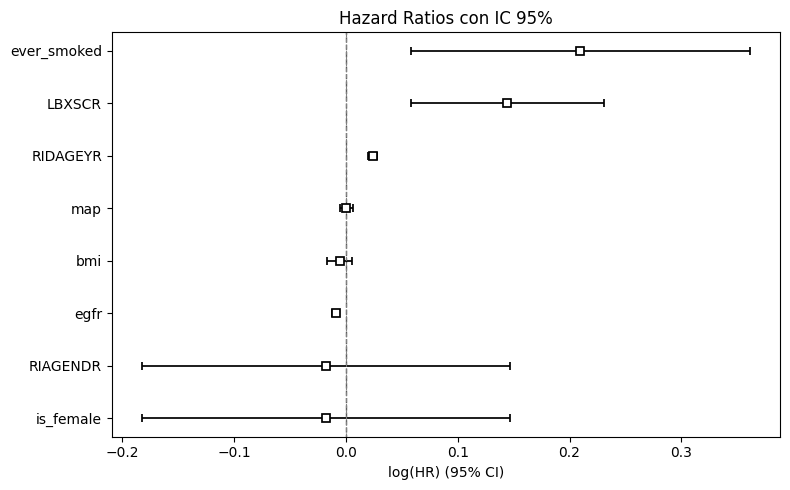

In [7]:
fig, ax = plt.subplots(figsize=(8, 5))
cph.plot(ax=ax)
ax.set_title('Hazard Ratios con IC 95%')
ax.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig(REPORT / 'hazard_ratios.png', dpi=120, bbox_inches='tight')
plt.show()

## 5. Evaluación en test — C-index

El **C-index** (Concordance Index) mide qué tan bien el modelo ordena correctamente los riesgos:

- `0.5` = no mejor que el azar (moneda al aire)
- `0.7` = bueno
- `0.8+` = excelente para datos clínicos observacionales

Preguntamos: *de todos los pares de pacientes donde uno murió antes que el otro, ¿en qué porcentaje el modelo asignó mayor riesgo al que murió primero?*

In [8]:
# Limpieza de NaN en test
test_cols = [c for c in test.columns if c not in {DURATION_COL, EVENT_COL}]
test_clean = test.dropna(subset=[DURATION_COL, EVENT_COL] + test_cols).copy()
print(f'Filas test antes de dropna: {len(test):,} → después: {len(test_clean):,}')

risk_scores = cph.predict_partial_hazard(test_clean)
c_index = concordance_index(
    test_clean[DURATION_COL],
    -risk_scores,
    test_clean[EVENT_COL],
)
print(f'\n→ C-index (train): {cph.concordance_index_:.4f}')
print(f'→ C-index (test):  {c_index:.4f}')
print(f'→ Diferencia:       {abs(cph.concordance_index_ - c_index):.4f} (< 0.01 = sin sobreajuste)')

metrics = {'c_index_train': round(cph.concordance_index_, 4),
            'c_index_test':  round(float(c_index), 4)}

Filas test antes de dropna: 1,183 → después: 1,004

→ C-index (train): 0.8324
→ C-index (test):  0.8316
→ Diferencia:       0.0008 (< 0.01 = sin sobreajuste)


## 6. Persistencia del modelo y métricas

In [9]:
with open(MODELS / 'cox_model.pkl', 'wb') as f:
    pickle.dump(cph, f)

with open(REPORT / 'metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print('✓ Modelo guardado en:', MODELS / 'cox_model.pkl')
print('✓ Métricas guardadas en:', REPORT / 'metrics.json')
print('\nMétricas finales:')
print(json.dumps(metrics, indent=2))

✓ Modelo guardado en: data\06_models\nhanes_2013_2014\cox_model.pkl
✓ Métricas guardadas en: data\08_reporting\nhanes_2013_2014\metrics.json

Métricas finales:
{
  "c_index_train": 0.8324,
  "c_index_test": 0.8316
}


## 7. Resumen y próximos pasos

| Aspecto | Resultado |
|---|---|
| Modelo | Cox Proportional Hazards (penalizer=0.1) |
| Participantes en train | ~4,730 |
| Participantes en test | ~1,183 |
| C-index train | ~0.83 |
| C-index test | ~0.83 |

**Interpretación:** El modelo discrimina bien el riesgo relativo entre participantes. La diferencia mínima entre train y test sugiere que no hay sobreajuste relevante.

**Próximos pasos:**
- Incorporar más variables de laboratorio (`LBXSGL`, `LBXSUA`)
- Explorar modelos alternativos (Random Survival Forest, Weibull AFT)
- Análisis de proporcionalidad del supuesto de Cox (`cph.check_assumptions()`)
- Segmentación por grupo etario o causa de muerte (`ucod_leading`)